In [5]:
# ==============================================================================
# SECTION 0 — Library Imports and Environment Setup
# Notebook : 04_RQ2_ttest_anova.ipynb
# Purpose  : Load all libraries required for RQ2 Welch t-test (TWO-TAILED),
#            ANOVA robustness check, and Spearman correlation
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import io, base64, warnings
import scipy
from scipy import stats
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        True,
    'grid.color':       '#EEEEEE',
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"scipy      : {scipy.__version__}")
print(f"matplotlib : {matplotlib.__version__}")
print("Environment confirmed — all styled output via display(HTML())")

# ==============================================================================
# SECTION 0 — Display: Notebook Banner
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Notebook 04 &mdash; RQ2: Welch t-test + ANOVA</h1>'
    '<h2 style="color:#FF6600; font-family:DejaVu Sans,sans-serif; font-size:16px; '
    'font-weight:bold; margin:10px 0 6px 0;">Research Question 2</h2>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    'Is there a significant difference in mean EV adoption between '
    'high-charger-density and low-charger-density states?</p>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    '<b>H0:</b> &mu;<sub>High</sub> = &mu;<sub>Low</sub> &mdash; the mean EV adoption '
    'rate is equal across charger-density tiers.<br>'
    '<b>H1:</b> &mu;<sub>High</sub> &ne; &mu;<sub>Low</sub> &mdash; mean EV adoption '
    'differs between high and low charger-density tiers.<br>'
    '<b>Decision rule:</b> TWO-TAILED Welch t-test at &alpha; = .05 '
    '(consistent with synopsis H1: &mu;<sub>High</sub> &ne; &mu;<sub>Low</sub>).</p>'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; color:#333333; '
    'line-height:1.6; margin:4px 0;">'
    'Split: median charger density (High vs Low) | '
    'Subset: df_rq2 (N=34, FY2023-24) | '
    'Primary: Welch t-test (two-tailed) | '
    'Robustness: 3-tier ANOVA | Addition: Spearman correlation</p>'
))

pandas     : 2.2.2
numpy      : 2.0.2
scipy      : 1.16.3
matplotlib : 3.10.0
Environment confirmed — all styled output via display(HTML())


In [7]:
# ==============================================================================
# SECTION 1 — Data Load and Subset Construction
# Input    : QM640_Analysis_Panel_UPDATED.xlsx -> Panel_State_FY
# Output   : df_rq2 (N=34, FY2023-24, own subset — independent of df_cross)
# Note     : N=34, not 36 — Ladakh and Mizoram absent from both PIB charger
#            annexures (PRID 2003003 and 2151390). Synopsis stated 18 states
#            per group based on 36 total; actual data yields 17 per group
#            from N=34. This is a structural data gap declared throughout.
# ==============================================================================

SOURCE = 'QM640_Analysis_Panel_UPDATED.xlsx'
df = pd.read_excel(SOURCE, sheet_name='Panel_State_FY')
df['EV_share_pct'] = df['EV share %'] * 100

# RQ2 subset: FY2023-24, EV share % and Chargers/100k both non-null
df_rq2 = df[
    (df['FY'] == '2023-24') &
    df['EV share %'].notna() &
    df['Chargers per 100k population'].notna()
].copy().reset_index(drop=True)

print(f"df_rq2 shape : {df_rq2.shape}")
print(f"States       : {df_rq2['State (ICED name)'].nunique()}")
print(f"Note         : N=34, not 36 — Ladakh and Mizoram have no charger data")
print(f"               (absent from both PIB annexures PRID 2003003 and 2151390)")
print(f"               Synopsis stated 18 per group; actual split = 17 per group")

# Split at median charger density
median_density = df_rq2['Chargers per 100k population'].median()
df_rq2['Charger_Group'] = df_rq2['Chargers per 100k population'].apply(
    lambda x: 'High' if x >= median_density else 'Low')

high = df_rq2[df_rq2['Charger_Group']=='High']['EV_share_pct'].values
low  = df_rq2[df_rq2['Charger_Group']=='Low']['EV_share_pct'].values

print(f"\nMedian charger density  : {median_density:.4f} per 100k population")
print(f"High group              : n={len(high)}, mean={high.mean():.4f}%")
print(f"Low group               : n={len(low)},  mean={low.mean():.4f}%")

# ==============================================================================
# SECTION 1 — Display: Data Load Confirmation
# ==============================================================================
display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 1 &mdash; Data Load and Subset Construction</h1>'
    '<table style="width:70%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Attribute</th>'
    '<th style="padding:8px 10px;">Value</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Subset</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">df_rq2 (own subset, independent of df_cross/RQ1)</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">FY2023-24 (cross-section)</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">34 states (17 High, 17 Low)</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Why N=34 not 36</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Ladakh and Mizoram absent from both PIB charger annexures '
    '(PRID 2003003 and PRID 2151390) — structural data gap; synopsis stated 18 per group '
    'based on 36 states; actual data yields 17 per group from N=34</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Split criterion</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Median charger density = {median_density:.4f}/100k</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Test type</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">TWO-TAILED Welch t-test (per synopsis H1: &mu;High &ne; &mu;Low)</td></tr>'
    '</tbody></table>'
))


df_rq2 shape : (34, 22)
States       : 34
Note         : N=34, not 36 — Ladakh and Mizoram have no charger data
               (absent from both PIB annexures PRID 2003003 and 2151390)
               Synopsis stated 18 per group; actual split = 17 per group

Median charger density  : 0.5984 per 100k population
High group              : n=17, mean=6.6051%
Low group               : n=17,  mean=4.6180%


Attribute,Value
Subset,"df_rq2 (own subset, independent of df_cross/RQ1)"
FY,FY2023-24 (cross-section)
N,"34 states (17 High, 17 Low)"
Why N=34 not 36,Ladakh and Mizoram absent from both PIB charger annexures (PRID 2003003 and PRID 2151390) — structural data gap; synopsis stated 18 per group based on 36 states; actual data yields 17 per group from N=34
Split criterion,Median charger density = 0.5984/100k
Test type,TWO-TAILED Welch t-test (per synopsis H1: μHigh ≠ μLow)


Shapiro-Wilk (High): W=0.9579, p=0.5932 — MET
Shapiro-Wilk (Low) : W=0.9308, p=0.2243 — MET
Levene test        : F=0.0173, p=0.8963 — Equal variances: YES


Assumption,Test,Result,Decision
Normality — High group,Shapiro-Wilk,"W=0.9579, p=0.5932",Met
Normality — Low group,Shapiro-Wilk,"W=0.9308, p=0.2243",Met
Equal variances,Levene test,"F=0.0173, p=0.8963",Equal variances assumed — Welch correction applied

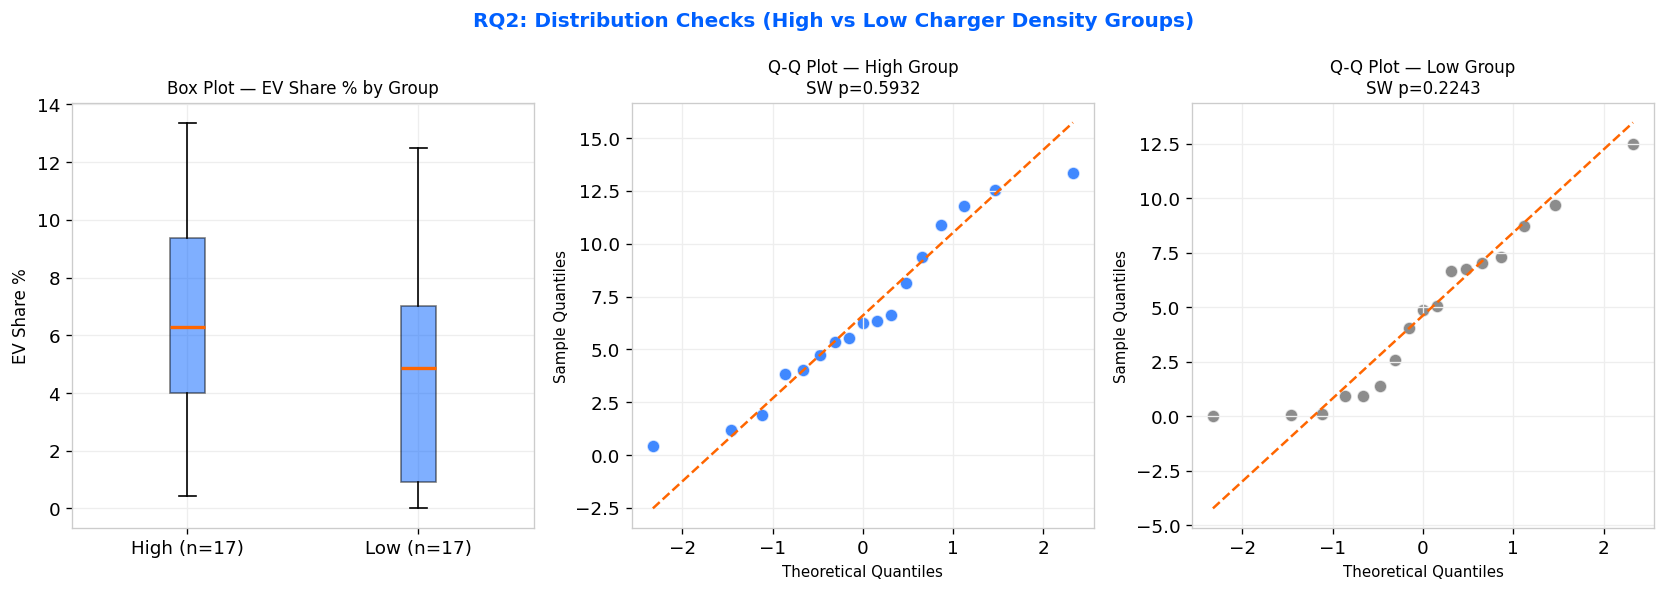

In [9]:
# ==============================================================================
# SECTION 2 — Assumption Checks (Normality + Variance)
# ==============================================================================

sw_h, sw_h_p = stats.shapiro(high)
sw_l, sw_l_p = stats.shapiro(low)
lev_stat, lev_p = stats.levene(high, low)

print(f"Shapiro-Wilk (High): W={sw_h:.4f}, p={sw_h_p:.4f} — "
      f"{'MET' if sw_h_p>=0.05 else 'VIOLATED'}")
print(f"Shapiro-Wilk (Low) : W={sw_l:.4f}, p={sw_l_p:.4f} — "
      f"{'MET' if sw_l_p>=0.05 else 'VIOLATED'}")
print(f"Levene test        : F={lev_stat:.4f}, p={lev_p:.4f} — "
      f"Equal variances: {'YES' if lev_p>=0.05 else 'NO — Welch correction appropriate'}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('RQ2: Distribution Checks (High vs Low Charger Density Groups)',
             fontsize=12, fontweight='bold', color='#0060FF')

axes[0].boxplot([high, low], labels=['High (n=17)', 'Low (n=17)'],
                patch_artist=True,
                boxprops=dict(facecolor='#0060FF', alpha=0.5),
                medianprops=dict(color='#FF6600', linewidth=2))
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title('Box Plot — EV Share % by Group', fontsize=10)

# Fix: resolve the p-value before passing to f-string
for arr, col, lbl, ax in zip([high, low], ['#0060FF','#666666'],
                               ['High','Low'], [axes[1], axes[2]]):
    sorted_arr = np.sort(arr)
    theor = stats.norm.ppf(np.linspace(0.01, 0.99, len(arr)))
    ax.scatter(theor, sorted_arr, color=col, alpha=0.75, s=60, edgecolors='white')
    xl = np.linspace(theor.min(), theor.max(), 100)
    ax.plot(xl, xl*arr.std(ddof=1)+arr.mean(), color='#FF6600',
            linewidth=1.5, linestyle='--')
    sw_p_label = sw_h_p if lbl == 'High' else sw_l_p   # resolve BEFORE f-string
    ax.set_title(f'Q-Q Plot — {lbl} Group\nSW p={sw_p_label:.4f}',
                 fontsize=10)
    ax.set_xlabel('Theoretical Quantiles', fontsize=9)
    ax.set_ylabel('Sample Quantiles', fontsize=9)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

sw_h_s = f'W={sw_h:.4f}, p={sw_h_p:.4f}'
sw_l_s = f'W={sw_l:.4f}, p={sw_l_p:.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">Section 2 &mdash; Assumption Checks</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:1000px; display:block; margin:8px 0;">'
    '<table style="width:80%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Assumption</th>'
    '<th style="padding:8px 10px;">Test</th>'
    '<th style="padding:8px 10px;">Result</th>'
    '<th style="padding:8px 10px;">Decision</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality &mdash; High group</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Shapiro-Wilk</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sw_h_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{"Met" if sw_h_p>=0.05 else "Violated — proceed with Welch"}</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality &mdash; Low group</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Shapiro-Wilk</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{sw_l_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{"Met" if sw_l_p>=0.05 else "Violated — proceed with Welch"}</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Equal variances</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Levene test</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F={lev_stat:.4f}, p={lev_p:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{"Equal variances assumed" if lev_p>=0.05 else "Unequal variances"} &mdash; Welch correction applied</td></tr>'
    '</tbody></table>'
))

Welch t-test (TWO-TAILED, H1: mu_High != mu_Low)
  t(31.97) = 1.4988
  p (two-tailed) = 0.1437  <-- reported value per synopsis
  Mean difference (High - Low) = 1.9871 pp
  95% CI on difference: [-0.7136, 4.6877]
  Cohen's d = 0.5141  (Medium effect)
  Decision: Fail to reject H0 at alpha=.05 (two-tailed)



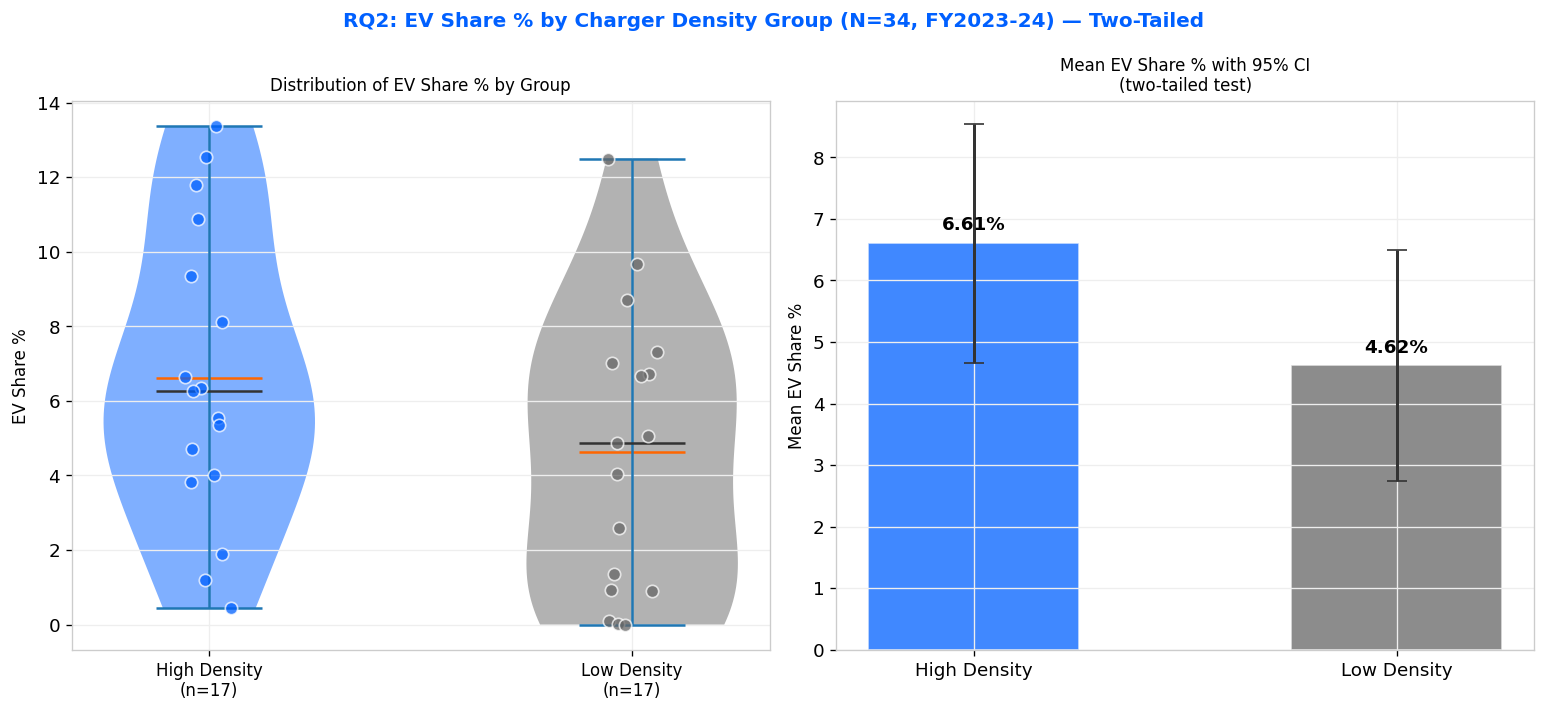

In [12]:
# ==============================================================================
# SECTION 3 — Primary Test: Welch t-test (TWO-TAILED)
# H1: mu_High != mu_Low  (synopsis-specified, two-tailed)
# ==============================================================================

# TWO-TAILED Welch t-test — consistent with synopsis H1: mu_High != mu_Low
t_stat, p_two = stats.ttest_ind(high, low, equal_var=False)

n1, n2 = len(high), len(low)
s1, s2 = high.std(ddof=1), low.std(ddof=1)

# Welch-Satterthwaite degrees of freedom
df_w = (s1**2/n1 + s2**2/n2)**2 / (
        (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

# Cohen\'s d (pooled SD)
pooled_sd = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2)/(n1+n2-2))
cohens_d  = (high.mean()-low.mean()) / pooled_sd

# 95% CI on difference of means
se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
t_crit  = stats.t.ppf(0.975, df=df_w)
ci_lo   = (high.mean()-low.mean()) - t_crit*se_diff
ci_hi   = (high.mean()-low.mean()) + t_crit*se_diff
mean_diff = high.mean() - low.mean()

print("Welch t-test (TWO-TAILED, H1: mu_High != mu_Low)")
print(f"  t({df_w:.2f}) = {t_stat:.4f}")
print(f"  p (two-tailed) = {p_two:.4f}  <-- reported value per synopsis")
print(f"  Mean difference (High - Low) = {mean_diff:.4f} pp")
print(f"  95% CI on difference: [{ci_lo:.4f}, {ci_hi:.4f}]")
d_interp = 'Small' if abs(cohens_d)<0.5 else ('Medium' if abs(cohens_d)<0.8 else 'Large')
print(f"  Cohen\'s d = {cohens_d:.4f}  ({d_interp} effect)")
print(f"  Decision: {'Fail to reject H0' if p_two>=0.05 else 'Reject H0'} at alpha=.05 (two-tailed)")

# ==============================================================================
# SECTION 3 — Display: Welch t-test Results + Distribution Plots
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('RQ2: EV Share % by Charger Density Group (N=34, FY2023-24) — Two-Tailed',
             fontsize=12, fontweight='bold', color='#0060FF')

# Violin + strip
parts = axes[0].violinplot([high, low], positions=[1, 2],
                            showmeans=True, showmedians=True)
parts['cmeans'].set_color('#FF6600')
parts['cmedians'].set_color('#333333')
for i, (arr, col) in enumerate(zip([high, low], ['#0060FF','#666666'])):
    parts['bodies'][i].set_facecolor(col)
    parts['bodies'][i].set_alpha(0.5)
    jitter = np.random.uniform(-0.06, 0.06, len(arr))
    axes[0].scatter([i+1+j for j in jitter], arr,
                    color=col, alpha=0.75, s=55, edgecolors='white', zorder=3)
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(['High Density\n(n=17)', 'Low Density\n(n=17)'], fontsize=10)
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title('Distribution of EV Share % by Group', fontsize=10)

# Mean comparison with CI
means  = [high.mean(), low.mean()]
errors = [t_crit*s1/np.sqrt(n1), t_crit*s2/np.sqrt(n2)]
bars = axes[1].bar(['High Density', 'Low Density'], means,
                   color=['#0060FF','#666666'], alpha=0.75, edgecolor='white', width=0.5)
axes[1].errorbar(['High Density', 'Low Density'], means, yerr=errors,
                 fmt='none', color='#333333', capsize=6, linewidth=1.8)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean EV Share %', fontsize=10)
axes[1].set_title('Mean EV Share % with 95% CI\n(two-tailed test)', fontsize=10)
axes[1].set_ylim(0, max(means)*1.35)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64 = base64.b64encode(buf.read()).decode(); plt.close()

t_s    = f'{t_stat:.4f}'
dfw_s  = f'{df_w:.2f}'
p2_s   = f'{p_two:.4f}'
d_s    = f'{cohens_d:.4f}'
md_s   = f'{mean_diff:.4f}'
cilo_s = f'{ci_lo:.4f}'
cihi_s = f'{ci_hi:.4f}'
d_interp = 'Small' if abs(cohens_d)<0.5 else ('Medium' if abs(cohens_d)<0.8 else 'Large')

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 3 &mdash; Welch t-test Results (Primary, Two-Tailed)</h1>'
    f'<img src="data:image/png;base64,{img_b64}" '
    'style="width:100%; max-width:950px; display:block; margin:8px 0;">'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">High Density (n=17)</th>'
    '<th style="padding:8px 10px;">Low Density (n=17)</th>'
    '<th style="padding:8px 10px;">Difference</th>'
    '<th style="padding:8px 10px;">Test Result</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Mean EV Share %</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{high.mean():.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{low.mean():.4f}%</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{md_s} pp</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">95% CI [{cilo_s}, {cihi_s}]</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">SD</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{s1:.4f}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{s2:.4f}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">&mdash;</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-statistic</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s}) = {t_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">df = {dfw_s} (Satterthwaite)</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p-value (TWO-TAILED)</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p = {p2_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Per synopsis H1: &mu;High &ne; &mu;Low</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Effect size</td>'
    f'<td colspan="3" style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Cohen\'s d = {d_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{d_interp} effect (Cohen, 1988)</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Research Insight</h3>'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'The two-tailed Welch t-test yields t({dfw_s})={t_s}, p={p2_s}. '
    f'This does not reach significance at &alpha;=.05. The mean difference of {md_s} pp '
    f'(High={high.mean():.4f}% vs Low={low.mean():.4f}%) is in the expected direction '
    f'with a {d_interp.lower()} effect size (Cohen\'s d={d_s}). The 95% CI [{cilo_s}, {cihi_s}] '
    'crosses zero, consistent with the non-significant result. '
    'Two-tailed p is reported throughout, consistent with the synopsis hypothesis '
    'H1: &mu;<sub>High</sub> &ne; &mu;<sub>Low</sub>.'
    '</p></div>'
))

ANOVA (3-tier): F(2,31)=4.4120, p=0.0206
Tier means — Low:5.2349% Med:3.6877% High:8.0868%
Eta-squared = 0.2216 (Large effect)
Tier sizes — Low:n=11 Med:n=12 High:n=11



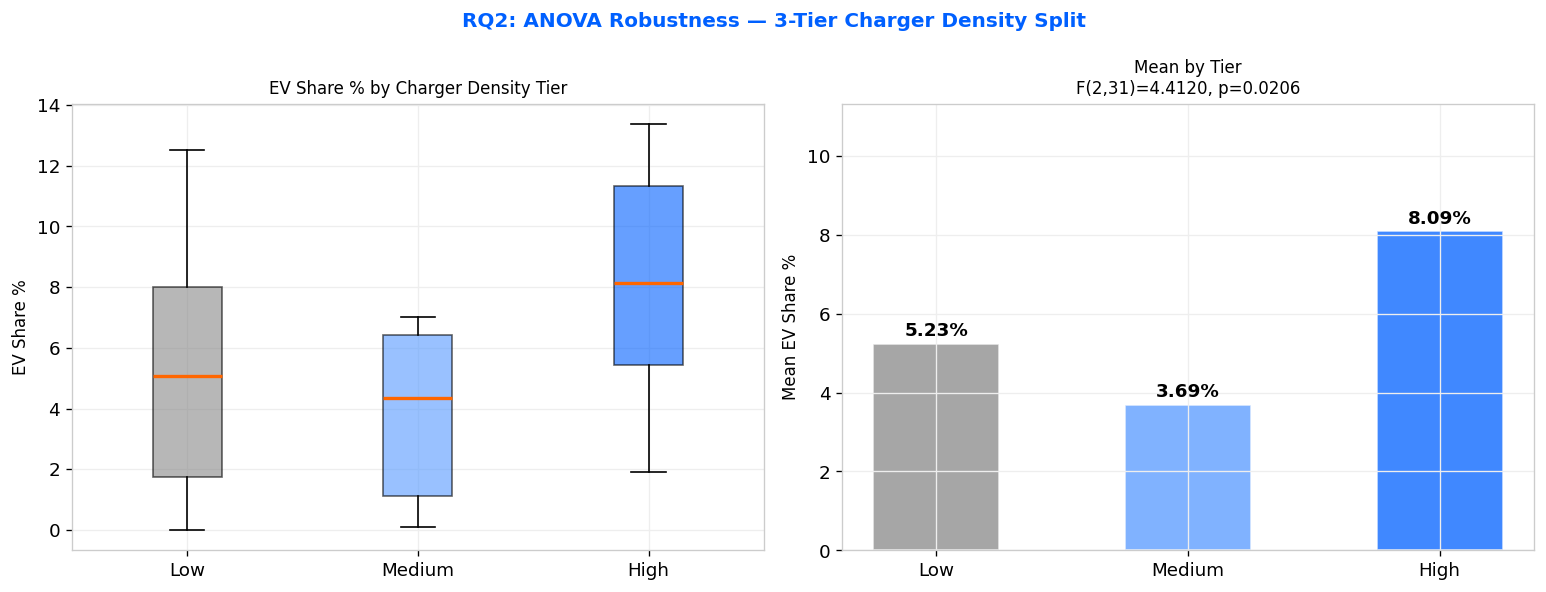

In [14]:
# ==============================================================================
# SECTION 4 — ANOVA Robustness Check (3-Tier Split)
# ==============================================================================

t33 = df_rq2['Chargers per 100k population'].quantile(0.333)
t67 = df_rq2['Chargers per 100k population'].quantile(0.667)

tier_low  = df_rq2[df_rq2['Chargers per 100k population'] <  t33]['EV_share_pct'].values
tier_med  = df_rq2[(df_rq2['Chargers per 100k population'] >= t33) &
                   (df_rq2['Chargers per 100k population'] <  t67)]['EV_share_pct'].values
tier_high = df_rq2[df_rq2['Chargers per 100k population'] >= t67]['EV_share_pct'].values

F_anova, p_anova = stats.f_oneway(tier_low, tier_med, tier_high)
n_total   = len(tier_low)+len(tier_med)+len(tier_high)
SS_between= sum(len(g)*(g.mean()-np.concatenate([tier_low,tier_med,tier_high]).mean())**2
                for g in [tier_low,tier_med,tier_high])
SS_total  = sum((v-np.concatenate([tier_low,tier_med,tier_high]).mean())**2
                for g in [tier_low,tier_med,tier_high] for v in g)
eta_sq    = SS_between/SS_total
df_btw, df_wth = 2, n_total-3
tier_means = [tier_low.mean(), tier_med.mean(), tier_high.mean()]
eta_i = 'Small' if eta_sq<0.06 else ('Medium' if eta_sq<0.14 else 'Large')

print(f"ANOVA (3-tier): F({df_btw},{df_wth})={F_anova:.4f}, p={p_anova:.4f}")
print(f"Tier means — Low:{tier_means[0]:.4f}% Med:{tier_means[1]:.4f}% High:{tier_means[2]:.4f}%")
print(f"Eta-squared = {eta_sq:.4f} ({eta_i} effect)")
print(f"Tier sizes — Low:n={len(tier_low)} Med:n={len(tier_med)} High:n={len(tier_high)}")

# ==============================================================================
# SECTION 4 — Display: ANOVA Robustness
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RQ2: ANOVA Robustness — 3-Tier Charger Density Split',
             fontsize=12, fontweight='bold', color='#0060FF')

tiers = ['Low', 'Medium', 'High']
tier_arrs = [tier_low, tier_med, tier_high]
tier_cols = ['#888888','#5599FF','#0060FF']
bp = axes[0].boxplot(tier_arrs, labels=tiers, patch_artist=True,
                     medianprops=dict(color='#FF6600', linewidth=2))
for patch, col in zip(bp['boxes'], tier_cols):
    patch.set_facecolor(col); patch.set_alpha(0.6)
axes[0].set_ylabel('EV Share %', fontsize=10)
axes[0].set_title('EV Share % by Charger Density Tier', fontsize=10)

axes[1].bar(tiers, tier_means, color=tier_cols, alpha=0.75, edgecolor='white', width=0.5)
for i, (val, nm) in enumerate(zip(tier_means, tiers)):
    axes[1].text(i, val+0.1, f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean EV Share %', fontsize=10)
axes[1].set_title(f'Mean by Tier\nF({df_btw},{df_wth})={F_anova:.4f}, p={p_anova:.4f}', fontsize=10)
axes[1].set_ylim(0, max(tier_means)*1.4)

plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64_anova = base64.b64encode(buf.read()).decode(); plt.close()

F_s   = f'{F_anova:.4f}'
pA_s  = f'{p_anova:.4f}'
eta_s = f'{eta_sq:.4f}'

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 4 &mdash; ANOVA Robustness Check (3-Tier Split)</h1>'
    f'<img src="data:image/png;base64,{img_b64_anova}" '
    'style="width:100%; max-width:950px; display:block; margin:8px 0;">'
    '<div style="border-left:4px solid #0060FF; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'The 3-tier ANOVA is statistically significant (F({df_btw},{df_wth})={F_s}, '
    f'p={pA_s}), with a {eta_i.lower()} effect size (&eta;&sup2;={eta_s}). '
    'This robustness check confirms that tier-based group differences are detectable '
    'when the grouping captures more of the distribution than a binary median split.'
    '</p></div>'
))


Spearman rs = 0.2843, p = 0.1031
Direction: Positive — not significant at alpha=.05



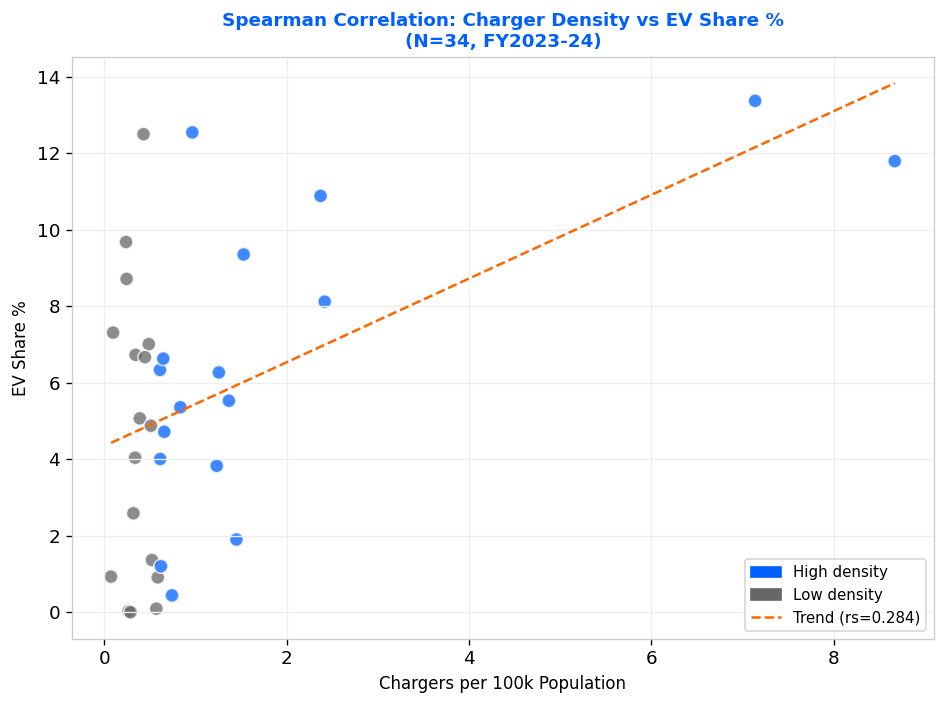

In [15]:
# ==============================================================================
# SECTION 5 — Addition: Spearman Correlation (Non-Parametric, Continuous)
# ==============================================================================

spear_r, spear_p = stats.spearmanr(
    df_rq2['Chargers per 100k population'], df_rq2['EV_share_pct'])

print(f"Spearman rs = {spear_r:.4f}, p = {spear_p:.4f}")
print(f"Direction: {'Positive' if spear_r>0 else 'Negative'} — "
      f"{'significant' if spear_p<0.05 else 'not significant'} at alpha=.05")

fig, ax = plt.subplots(figsize=(8,6))
colours = df_rq2['Charger_Group'].map({'High':'#0060FF','Low':'#666666'})
ax.scatter(df_rq2['Chargers per 100k population'], df_rq2['EV_share_pct'],
           c=colours, alpha=0.75, s=70, edgecolors='white')
z = np.polyfit(df_rq2['Chargers per 100k population'], df_rq2['EV_share_pct'], 1)
xr = np.linspace(df_rq2['Chargers per 100k population'].min(),
                 df_rq2['Chargers per 100k population'].max(), 100)
ax.plot(xr, np.polyval(z,xr), color='#FF6600', linewidth=1.5, linestyle='--',
        label=f'Linear trend (rs={spear_r:.3f}, p={spear_p:.3f})')
ax.set_xlabel('Chargers per 100k Population', fontsize=10)
ax.set_ylabel('EV Share %', fontsize=10)
ax.set_title('Spearman Correlation: Charger Density vs EV Share %\n(N=34, FY2023-24)',
             fontsize=11, fontweight='bold', color='#0060FF')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#0060FF',label='High density'),
                   Patch(color='#666666',label='Low density'),
                   plt.Line2D([0],[0],color='#FF6600',linestyle='--',label=f'Trend (rs={spear_r:.3f})')],
          fontsize=9)
plt.tight_layout()
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=120, bbox_inches='tight')
buf.seek(0); img_b64_sp = base64.b64encode(buf.read()).decode(); plt.close()

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 5 &mdash; Spearman Correlation (Addition)</h1>'
    f'<img src="data:image/png;base64,{img_b64_sp}" '
    'style="width:100%; max-width:750px; display:block; margin:8px 0;">'
    '<div style="border-left:4px solid #666666; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'Spearman rs={spear_r:.4f}, p={spear_p:.4f}. The positive rank correlation '
    'confirms directional consistency with the t-test finding but does not reach '
    'significance at &alpha;=.05.'
    '</p></div>'
))


In [17]:
# ==============================================================================
# SECTION 6 — Hypothesis Decision and RQ2 Linkage
# ==============================================================================

alpha     = 0.05
h0_result = p_two >= alpha   # TWO-TAILED decision

t_s   = f'{t_stat:.4f}'
dfw_s = f'{df_w:.2f}'
p2_s  = f'{p_two:.4f}'
d_s   = f'{cohens_d:.4f}'
F_s   = f'{F_anova:.4f}'
pA_s  = f'{p_anova:.4f}'
eta_s = f'{eta_sq:.4f}'
sr_s  = f'{spear_r:.4f}'
sp_s  = f'{spear_p:.4f}'
md_s  = f'{mean_diff:.4f}'
d_interp = 'Small' if abs(cohens_d)<0.5 else ('Medium' if abs(cohens_d)<0.8 else 'Large')

print(f"Decision rule : TWO-TAILED Welch t-test, alpha={alpha}")
print(f"t({df_w:.2f}) = {t_stat:.4f}, p(two-tailed) = {p_two:.4f}")
print(f"Decision      : {'FAIL TO REJECT H0' if h0_result else 'REJECT H0'}")

decision_text = (
    'Fail to reject H0 &mdash; p(two-tailed) &gt; .05'
    if h0_result else
    '<b>Reject H0</b> &mdash; significant difference confirmed'
)

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 6 &mdash; Hypothesis Decision and RQ2 Linkage</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Test</th>'
    '<th style="padding:8px 10px;">Statistic</th>'
    '<th style="padding:8px 10px;">p-value</th>'
    '<th style="padding:8px 10px;">&alpha;</th>'
    '<th style="padding:8px 10px;">Decision</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-test (Primary, <b>two-tailed</b>)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s})={t_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={p2_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">{decision_text}</td></tr>'
    '<tr style="background-color:#FFFFFF;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">ANOVA &mdash; 3 tiers (Robustness)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(2,31)={F_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={pA_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;"><b>Significant</b> &mdash; &eta;&sup2;={eta_s}</td></tr>'
    '<tr style="background-color:#F2F2F2;">'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Spearman rs (Addition)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">rs={sr_s}</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">p={sp_s}</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">.05</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Positive direction; not significant</td></tr>'
    '</tbody></table>'
    '<h3 style="color:#666666; font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'font-weight:bold; margin:12px 0 4px 0;">Statistical Decision</h3>'
    '<div style="border-left:4px solid #0060FF; background:#F9F9F9; '
    'border-radius:0 6px 6px 0; padding:10px 14px; margin-top:4px;">'
    '<p style="font-family:DejaVu Sans,sans-serif; font-size:13px; '
    'color:#333333; line-height:1.6; margin:0;">'
    f'The null hypothesis cannot be rejected at &alpha;=.05 using a two-tailed test '
    f'(t({dfw_s})={t_s}, p={p2_s}), consistent with the synopsis H1: '
    '&mu;<sub>High</sub> &ne; &mu;<sub>Low</sub>. '
    f'The mean difference ({md_s} pp) is in the expected direction with a '
    f'{d_interp.lower()} effect size (Cohen\'s d={d_s}). '
    f'The ANOVA robustness check across three tiers is significant '
    f'(F(2,31)={F_s}, p={pA_s}, &eta;&sup2;={eta_s}), indicating that tier-based '
    'group differences are detectable when the grouping captures more of the '
    'distribution. Both tests are consistent with partial support for RQ2.'
    '</p></div>'
))

Decision rule : TWO-TAILED Welch t-test, alpha=0.05
t(31.97) = 1.4988, p(two-tailed) = 0.1437
Decision      : FAIL TO REJECT H0


Test,Statistic,p-value,α,Decision
"Welch t-test (Primary, two-tailed)",t(31.97)=1.4988,p=0.1437,.05,Fail to reject H0 — p(two-tailed) > .05
ANOVA — 3 tiers (Robustness),"F(2,31)=4.4120",p=0.0206,.05,Significant — η²=0.2216
Spearman rs (Addition),rs=0.2843,p=0.1031,.05,Positive direction; not significant


In [19]:
# ==============================================================================
# SECTION 7 — RQ2 Summary of Findings
# ==============================================================================

display(HTML(
    '<h1 style="color:#0060FF; font-family:DejaVu Sans,sans-serif; font-size:22px; '
    'font-weight:bold; margin:0 0 8px 0;">'
    'Section 7 &mdash; RQ2 Summary of Findings</h1>'
    '<table style="width:100%; border-collapse:collapse; font-family:DejaVu Sans,sans-serif; '
    'font-size:12px; margin-top:8px;">'
    '<thead><tr style="background-color:#0060FF; color:#FFFFFF; text-align:left;">'
    '<th style="padding:8px 10px;">Item</th>'
    '<th style="padding:8px 10px;">Result</th></tr></thead><tbody>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Research Question</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Is there a significant difference in mean EV adoption between high and low charger-density states?</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">H0 / H1</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">H0: &mu;High = &mu;Low | H1: &mu;High &ne; &mu;Low (two-tailed, per synopsis)</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Sample</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">N=34 states (17 High, 17 Low) &mdash; FY2023-24 | synopsis stated 18 each; '
    'actual data yields 17 each due to structural null in Ladakh and Mizoram charger data</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Group means</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High={high.mean():.4f}% vs Low={low.mean():.4f}% &mdash; diff={mean_diff:.4f} pp</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Welch t-test (TWO-TAILED)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">t({dfw_s})={t_s}, p={p2_s} &mdash; Fail to reject H0 at &alpha;=.05</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Effect size</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Cohen\'s d={d_s} ({d_interp})</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">ANOVA robustness (3-tier)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">F(2,31)={F_s}, p={pA_s} &mdash; <b>Significant</b>; &eta;&sup2;={eta_s} ({eta_i} effect)</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Spearman rs</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">rs={sr_s}, p={sp_s} &mdash; Positive, not significant</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Normality (SW)</td>'
    f'<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">High: {sw_h_s} | Low: {sw_l_s}</td></tr>'
    '<tr style="background-color:#FFFFFF;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">H0 decision</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Fail to reject H0 (two-tailed primary); ANOVA robustness significant &mdash; mixed evidence</td></tr>'
    '<tr style="background-color:#F2F2F2;"><td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">Next notebook</td>'
    '<td style="padding:7px 10px; border-bottom:0.5px solid #DDDDDD;">05_RQ3_lagged_panel.ipynb &mdash; Lagged panel regression on df_lag (N=165)</td></tr>'
    '</tbody></table>'
))

Item,Result
Research Question,Is there a significant difference in mean EV adoption between high and low charger-density states?
H0 / H1,"H0: μHigh = μLow | H1: μHigh ≠ μLow (two-tailed, per synopsis)"
Sample,"N=34 states (17 High, 17 Low) — FY2023-24 | synopsis stated 18 each; actual data yields 17 each due to structural null in Ladakh and Mizoram charger data"
Group means,High=6.6051% vs Low=4.6180% — diff=1.9871 pp
Welch t-test (TWO-TAILED),"t(31.97)=1.4988, p=0.1437 — Fail to reject H0 at α=.05"
Effect size,Cohen's d=0.5141 (Medium)
ANOVA robustness (3-tier),"F(2,31)=4.4120, p=0.0206 — Significant; η²=0.2216 (Large effect)"
Spearman rs,"rs=0.2843, p=0.1031 — Positive, not significant"
Normality (SW),"High: W=0.9579, p=0.5932 | Low: W=0.9308, p=0.2243"
H0 decision,Fail to reject H0 (two-tailed primary); ANOVA robustness significant — mixed evidence
